# 1. Setup & Configuration
Import necessary libraries (`pandas`, `seaborn`, `matplotlib`) and define the helper function to load CSV files safely.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define your data path
DATA_PATH = r"C:\AINutriCare\Data\Raw"

# Set plot style and a more compact figure size
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

def load_file(filename, nrows=None):
    """Helper to load files safely."""
    file_path = os.path.join(DATA_PATH, filename)
    if not os.path.exists(file_path):
        print(f"[WARNING] File not found: {filename}")
        return None
    print(f"Loading {filename}...")
    return pd.read_csv(file_path, nrows=nrows)

# 2. Patient Demographics Analysis
**File:** `patients.csv`
**Goal:** Analyze the Age and Gender distribution. 

Loading patients.csv...
Total Patients: 100


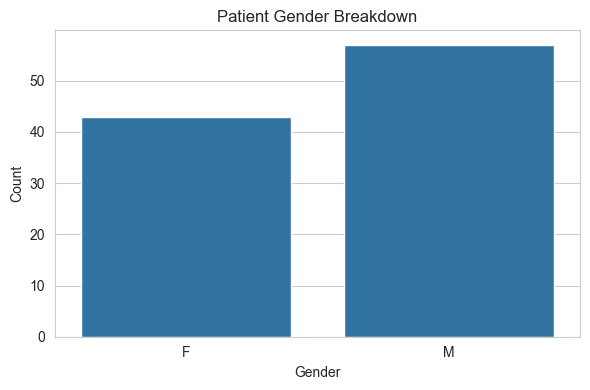

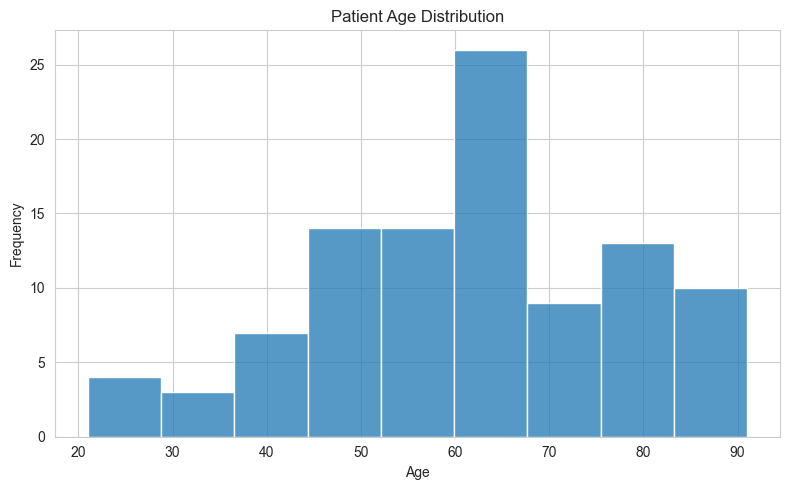

In [ ]:
# Load patients data
df_patients = load_file("patients.csv")

if df_patients is not None:
    print(f"Total Patients: {len(df_patients)}")
    
    # 1. Gender Distribution Plot
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_patients, x='gender')
    plt.title("Patient Gender Breakdown")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # 2. Age Distribution Plot
    plt.figure(figsize=(8, 5))
    sns.histplot(df_patients['anchor_age'])
    plt.title("Patient Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 3. Lab Results Overview
**Files:** `labevents.csv` and `d_labitems.csv`
**Goal:** Identify the most common lab tests. We merge the raw data with the dictionary to see readable names (e.g., "Glucose" instead of "50931").

Loading labevents.csv...
Loading d_labitems.csv...


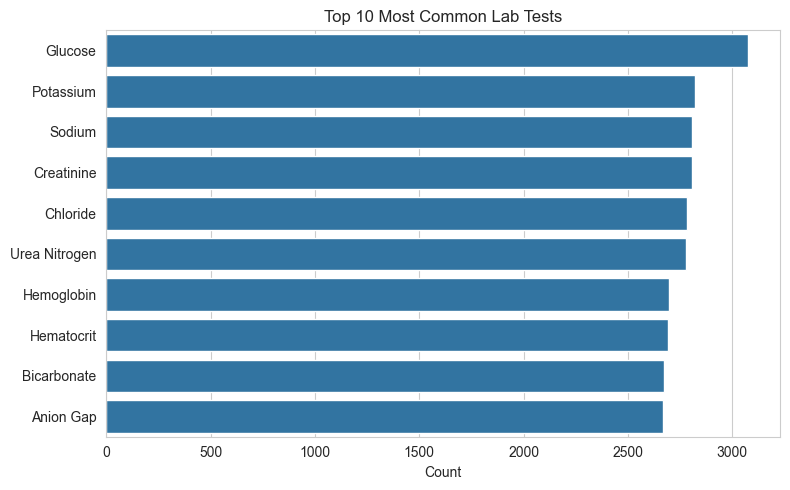

In [17]:
# Load a sample of lab events (100k rows) for speed
df_labs = load_file("labevents.csv", nrows=100000) 
df_lab_codes = load_file("d_labitems.csv")

if df_labs is not None and df_lab_codes is not None:
    # Merge to get the English name of the test
    df_labs_merged = pd.merge(df_labs, df_lab_codes, on='itemid', how='left')
    
    # Identify Top 10 Tests
    top_tests = df_labs_merged['label'].value_counts().head(10)
    
    # Plot: Top 10 Lab Tests
    plt.figure(figsize=(8, 5))
    sns.barplot(y=top_tests.index, x=top_tests.values)
    plt.title("Top 10 Most Common Lab Tests")
    plt.xlabel("Count")
    plt.ylabel("") # Remove y-label to save space
    plt.tight_layout()
    plt.show()

# 4.Glucose Distribution
**Goal:** Verify that the dataset contains enough blood sugar data to train a Diabetes Detection Model.
* **X-Axis:** Blood Glucose Level (mg/dL)
* **Y-Axis:** Frequency (Count)
* **Observation:** A "tail" extending to the right (>140 mg/dL) indicates the presence of diabetic patients.

Found 3098 glucose records.
Average Glucose: 151.69 mg/dL


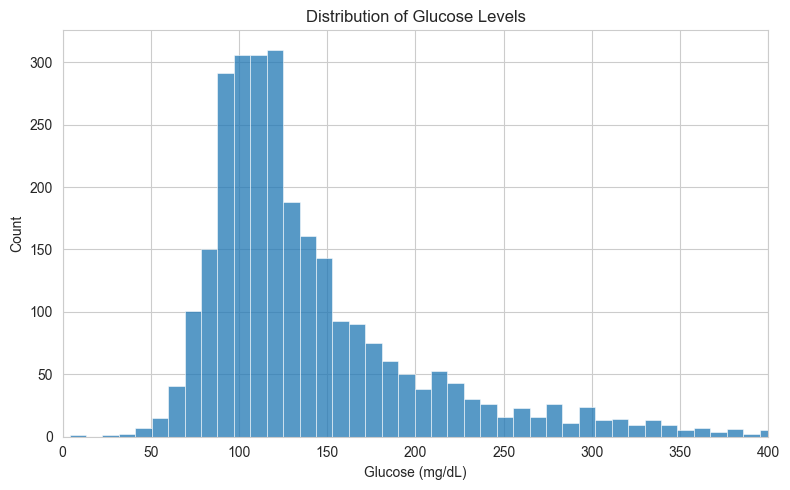

In [ ]:
if df_labs is not None:
    # Filter for Glucose tests
    glucose_data = df_labs_merged[df_labs_merged['label'].str.contains("Glucose", case=False, na=False)]
    
    if not glucose_data.empty:
        print(f"Found {len(glucose_data)} glucose records.")
        print(f"Average Glucose: {glucose_data['valuenum'].mean():.2f} mg/dL")

        # Plot: Glucose Distribution
        plt.figure(figsize=(8, 5))
        sns.histplot(glucose_data['valuenum'].dropna())
        plt.title("Distribution of Glucose Levels")
        plt.xlabel("Glucose (mg/dL)")
        plt.xlim(0, 400)
        plt.tight_layout()
        plt.show()
    else:
        print("No Glucose data found in this sample.")

# 5. Prescription Analysis
**File:** `prescriptions.csv`
**Goal:** Identify common medications to build "Food-Drug Interaction" rules (e.g., Insulin requires specific diet rules).

Loading prescriptions.csv...


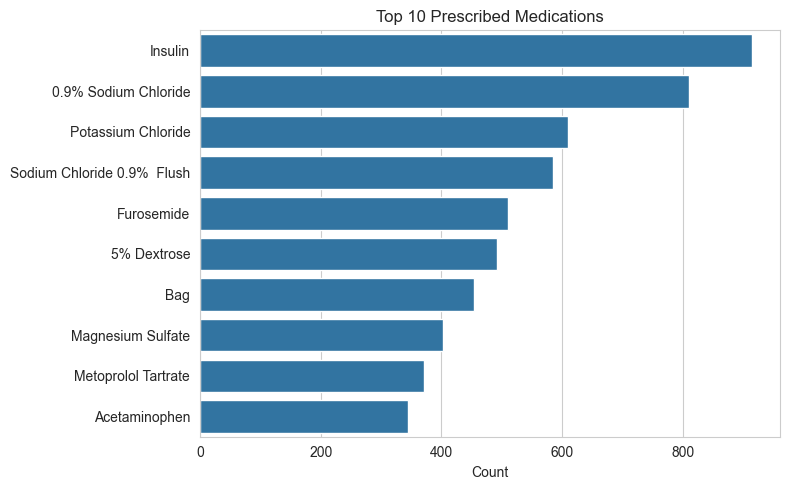

In [21]:
# Load prescriptions
df_meds = load_file("prescriptions.csv", nrows=50000)

if df_meds is not None:
    # Identify Top 10 Drugs
    top_drugs = df_meds['drug'].value_counts().head(10)
    
    # Plot: Top 10 Drugs
    plt.figure(figsize=(8, 5))
    sns.barplot(y=top_drugs.index, x=top_drugs.values)
    plt.title("Top 10 Prescribed Medications")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# 6. Vital Signs Check (BMI Data)
**File:** `omr.csv`
**Goal:** Check for "Weight" and "Height" records. These are required to calculate BMI and Calorie Needs.

In [13]:
# Load OMR (Vitals)
df_omr = load_file("omr.csv")

if df_omr is not None:
    print("Unique Vital Signs found:", df_omr['result_name'].unique())
    
    # Search for Weight
    weight_data = df_omr[df_omr['result_name'].str.contains("Weight", case=False, na=False)]
    
    print(weight_data[['result_name', 'result_value']].head(10))
    

Loading omr.csv...
Unique Vital Signs found: ['Height (Inches)' 'Weight (Lbs)' 'BMI (kg/m2)' 'Blood Pressure'
 'Blood Pressure Standing (1 min)' 'Blood Pressure Sitting'
 'Blood Pressure Lying' 'Blood Pressure Standing (3 mins)']
     result_name result_value
1   Weight (Lbs)          127
2   Weight (Lbs)          135
3   Weight (Lbs)          136
4   Weight (Lbs)          136
5   Weight (Lbs)          139
6   Weight (Lbs)          141
7   Weight (Lbs)          141
25  Weight (Lbs)          146
26  Weight (Lbs)          150
27  Weight (Lbs)          150
